***Task 1***

**Imports for Task 1**

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

**Diabetes Dataset for Regression**

Check for missing values, remove outliers, conduct statistical analysis

In [2]:
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
df = pd.DataFrame(X, columns=diabetes.feature_names)
df['target'] = y

print(f"Features: {list(diabetes.feature_names)}")

Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [3]:
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [4]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [5]:
# Calculate IQR for the numerical features (excluding target if preferred)
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Define the filtering condition
# We keep rows where all features are within 1.5 * IQR of the quartiles
outlier_condition = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)
df_cleaned = df[~outlier_condition]

# Update variables for the rest of Task 1 and Task 2
cleaned_diabetes_X = df_cleaned.drop(columns=['target']).values
cleaned_diabetes_y = df_cleaned['target'].values

print(f"Removed {len(df) - len(df_cleaned)} outliers.")

Removed 31 outliers.


Box Plot of Diabetes Dataset Features

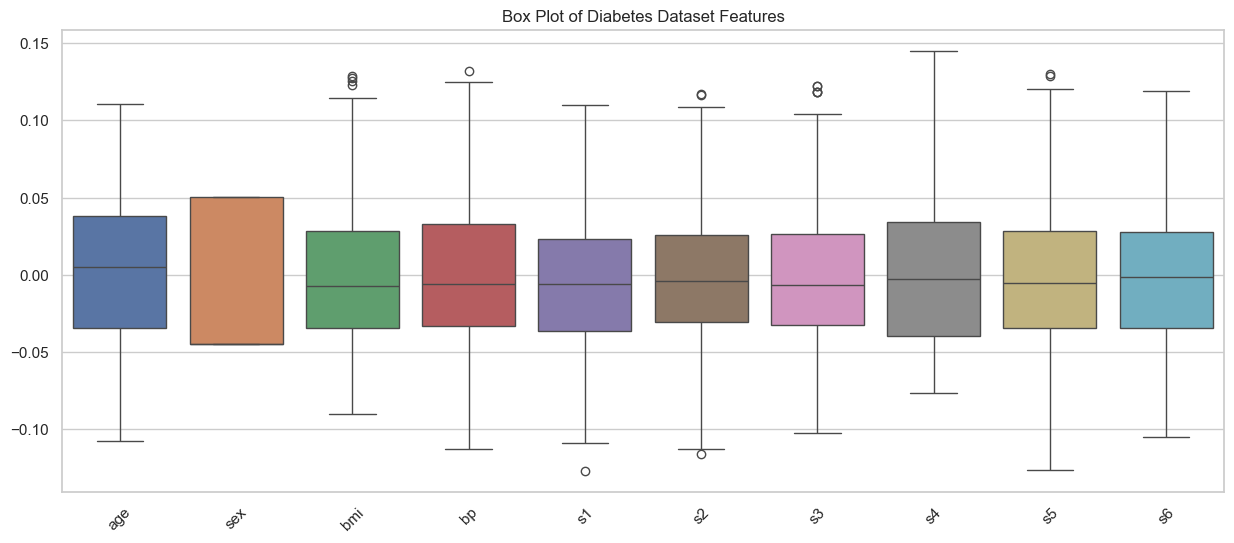

In [6]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_cleaned.drop(columns=['target']))
plt.title('Box Plot of Diabetes Dataset Features')
plt.xticks(rotation=45)
plt.show()

Histogram of Diabetes Dataset Features

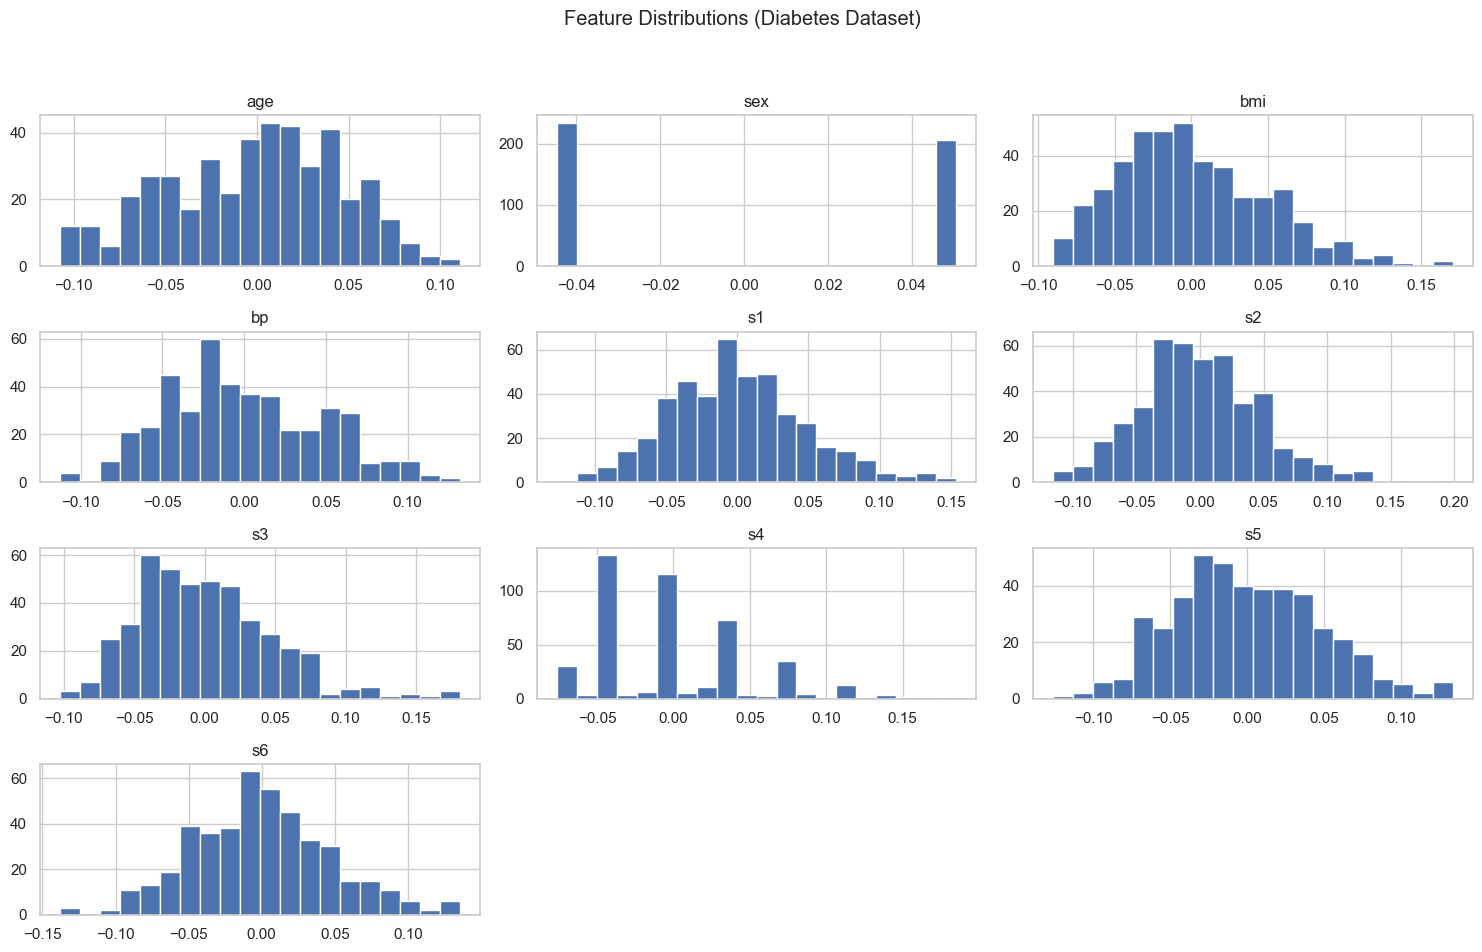

In [7]:
df.drop(columns='target').hist(bins=20, figsize=(15, 10))
plt.suptitle("Feature Distributions (Diabetes Dataset)")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Correlation Heatmap of the Diabetes Dataset

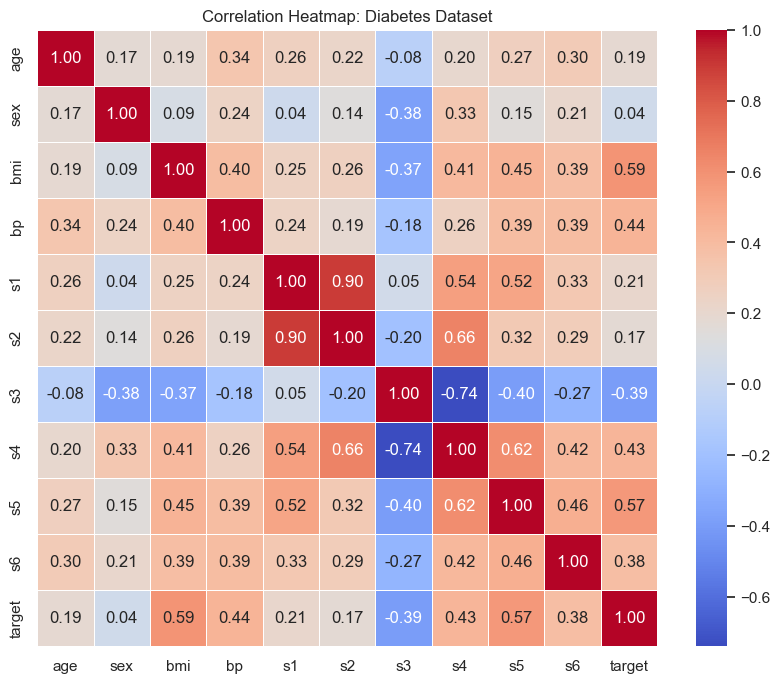

In [8]:
corr_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Diabetes Dataset')
plt.show()

BMI vs. Disease Progression and s5 vs. Disease Progression

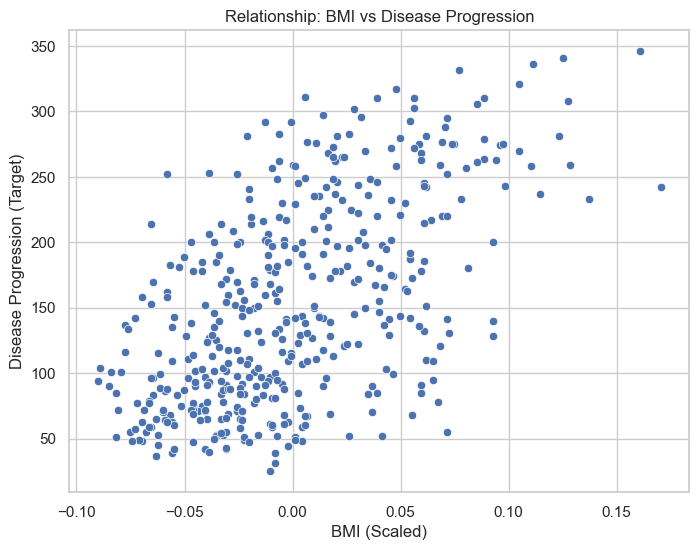

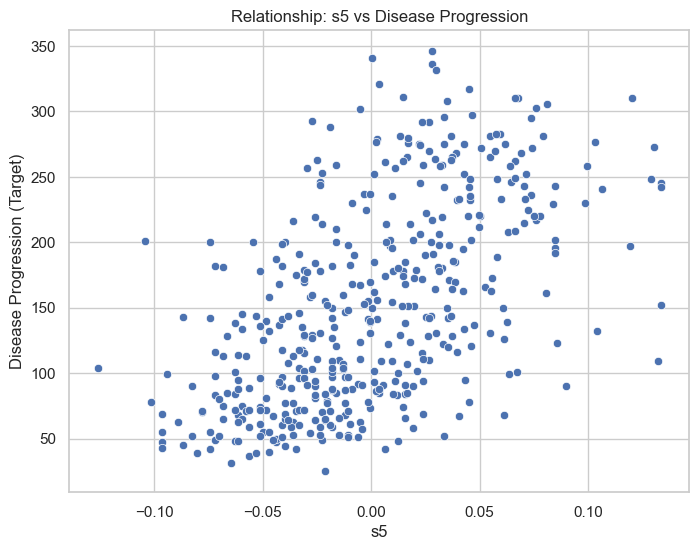

In [9]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='bmi', y='target', data=df)

plt.title('Relationship: BMI vs Disease Progression')
plt.xlabel('BMI (Scaled)')
plt.ylabel('Disease Progression (Target)')
plt.grid(True)
plt.show()
plt.figure(figsize=(8, 6))
sns.scatterplot(x='s5', y='target', data=df)

plt.title('Relationship: s5 vs Disease Progression')
plt.xlabel('s5')
plt.ylabel('Disease Progression (Target)')
plt.grid(True)
plt.show()

**Digits Dataset for Classification**

Load Digits dataset, check for missing values, check for erroneous values, conduct statistical analysis

In [10]:
digits = load_digits()
X = digits.data
y = digits.target

df_digits = pd.DataFrame(X)
df_digits['label'] = y

print(f"Dataset shape: {df_digits.shape}") 

Dataset shape: (1797, 65)


In [11]:
missing_values = df_digits.isnull().sum()

print(f"Total missing values: {missing_values.sum()}")

print(missing_values[missing_values > 0])

Total missing values: 0
Series([], dtype: int64)


In [12]:
out_of_range = (df_digits.iloc[:, :-1] < 0).any().any() or (df_digits.iloc[:, :-1] > 16).any().any()

print(f"Are there erroneous pixel values? {out_of_range}")

Are there erroneous pixel values? False


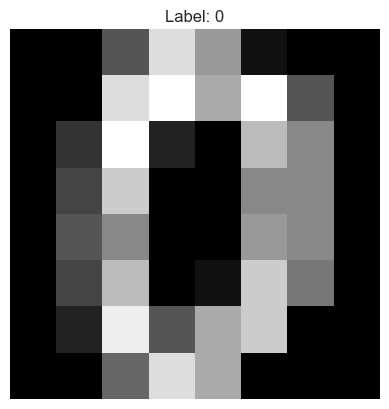

In [13]:
first_digit = X[0].reshape(8, 8)

plt.imshow(first_digit, cmap='gray')
plt.title(f"Label: {y[0]}")
plt.axis('off')
plt.show()

In [14]:
df_digits.describe()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,label
count,1797.0,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,...,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000,1797.000000
mean,0.0,0.303840,5.204786,11.835838,11.848080,5.781859,1.362270,0.129661,0.005565,1.993879,...,0.206455,0.000556,0.279354,5.557596,12.089037,11.809126,6.764051,2.067891,0.364496,4.490818
std,0.0,0.907192,4.754826,4.248842,4.287388,5.666418,3.325775,1.037383,0.094222,3.196160,...,0.984401,0.023590,0.934302,5.103019,4.374694,4.933947,5.900623,4.090548,1.860122,2.865304
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,1.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,11.000000,10.000000,0.000000,0.000000,0.000000,2.000000
50%,0.0,0.000000,4.000000,13.000000,13.000000,4.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,4.000000,13.000000,14.000000,6.000000,0.000000,0.000000,4.000000
75%,0.0,0.000000,9.000000,15.000000,15.000000,11.000000,0.000000,0.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,10.000000,16.000000,16.000000,12.000000,2.000000,0.000000,7.000000
max,0.0,8.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,2.000000,16.000000,...,13.000000,1.000000,9.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,9.000000


In [15]:
pixel_corr = df_digits.corr()['label'].sort_values(ascending=False)
print(pixel_corr.head())

label    1.000000
27       0.275468
35       0.265880
28       0.234159
29       0.216130
Name: label, dtype: float64


Distribution of pixels for different digits

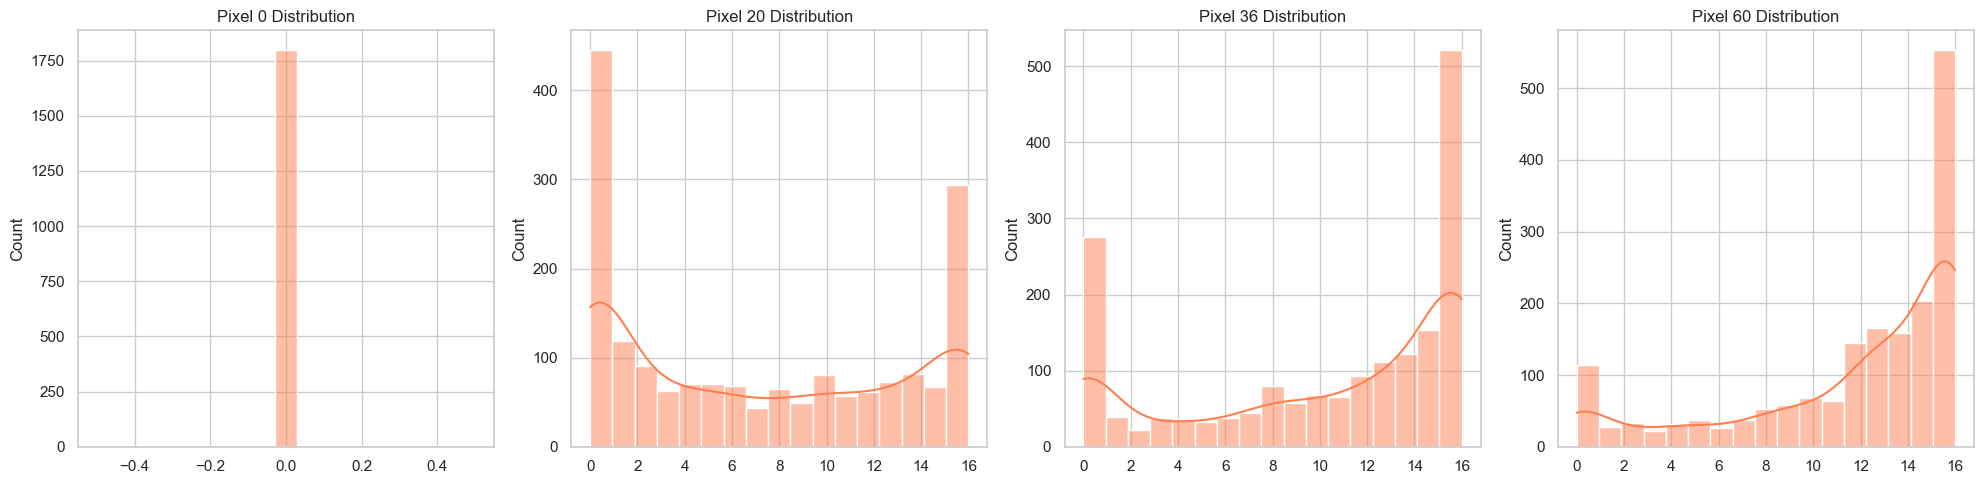

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
pixels_to_check = [0, 20, 36, 60] 

for i, p in enumerate(pixels_to_check):
    sns.histplot(X[:, p], bins=17, kde=True, ax=axes[i], color='coral')
    axes[i].set_title(f'Pixel {p} Distribution')

plt.tight_layout()
plt.show()

***Task 2***

Imports for Task 2

In [17]:
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

**Lasso Regression**

Implementation of Lasso Regression

In [18]:
class LassoRegression():

    def __init__(self, learning_rate, iterations, penalty):

        self.learning_rate = learning_rate
        self.iterations = iterations
        self.penalty = penalty  # Lambda

        self.X = None
        self.Y = None
        self.weights = None
        self.bias = None

    def fit(self, X, Y):

        self.X = X  # 442 rows (patients), 10 (cols) features
        self.Y = Y  # diabetes target values

        self.weights = np.zeros(X.shape[1])  # a vector of 0s with length 10, one for each feature, starting with 0s
        self.bias = 0  # starting bias is 0

        for i in range(self.iterations):
            self.update_weights()

    def update_weights(self):

        sample_number = self.X.shape[0]
        Y_pred = self.predict(self.X)

        dw = (2 / sample_number) * (self.X.T @ (Y_pred - self.Y))  # dw is a matrix, only consider MSE
        db = (2 / sample_number) * np.sum(Y_pred - self.Y)  # db is a number

        self.weights -= self.learning_rate * dw
        self.bias -= self.learning_rate * db

        # Soft thresholding: S(z) = sign(z) · max(|z| − ηλ , 0)
        self.weights = np.sign(self.weights) * np.maximum(np.abs(self.weights) - self.learning_rate * self.penalty, 0)

    def predict(self, X):

        return X @ self.weights + self.bias  # Y_pred = sum(weight * X) + bias

Diabetes dataset pre-processing

In [19]:
X = cleaned_diabetes_X
Y = cleaned_diabetes_y
scalar = StandardScaler()  # standardize
X = scalar.fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 42)

Function to calculate MSE

In [20]:
def mse(Y_true, Y_pred):
    return np.mean((Y_true - Y_pred) ** 2)

Effect of Penalty on MSE

Learning Rate = 0.01 and Iterations = 2000 remain unchanged

-----------------------------------------------------------

With Penalty =  0 , Lasso Regression has MSE of  2839.3646666889767
Weights: [ -3.14, -9.17, 23.15, 14.06, -2.77, -4.25, -7.18, 3.93, 25.79, 2.00 ]
Biases:  151.15631309503632

-----------------------------------------------------------

With Penalty =  0.001 , Lasso Regression has MSE of  2839.380226342773
Weights: [ -3.14, -9.17, 23.15, 14.06, -2.77, -4.25, -7.18, 3.92, 25.79, 2.00 ]
Biases:  151.15623446206592

-----------------------------------------------------------

With Penalty =  0.01 , Lasso Regression has MSE of  2839.520709255476
Weights: [ -3.13, -9.16, 23.15, 14.06, -2.75, -4.24, -7.20, 3.89, 25.79, 1.99 ]
Biases:  151.15552676530146

-----------------------------------------------------------

With Penalty =  0.1 , Lasso Regression has MSE of  2840.9700183151785
Weights: [ -3.07, -9.07, 23.12, 14.00, -2.58, -4.16, -7.38, 3.57, 25.76, 1.95 ]
Biases:  

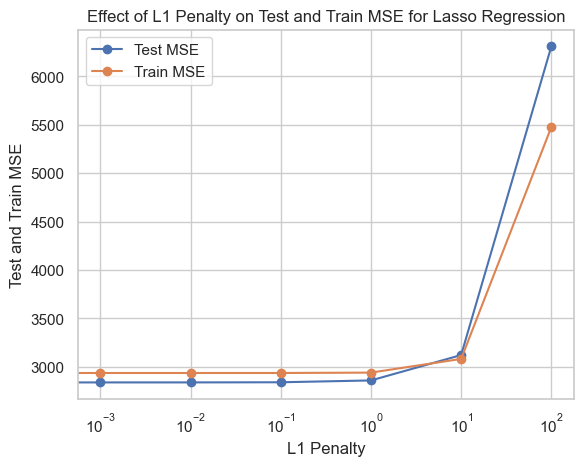

In [21]:
penalties = [0, 0.001, 0.01, 0.1, 1, 10, 100]
test_mse_values = []
train_mse_values = []

print("Learning Rate = 0.01 and Iterations = 2000 remain unchanged")
print("\n-----------------------------------------------------------")

for penalty in penalties:
    lasso = LassoRegression(learning_rate = 0.01, iterations = 2000, penalty = penalty)
    lasso.fit(X_train, Y_train)
    Y_pred = lasso.predict(X_test)
    Y_trained = lasso.predict(X_train)
    test_mse_value = mse(Y_test, Y_pred)
    train_mse_value = mse(Y_train, Y_trained)
    print("\nWith Penalty = ", penalty, ", Lasso Regression has MSE of ", test_mse_value)
    weights_str = ', '.join(f"{w:.2f}" for w in lasso.weights)
    print("Weights: [", weights_str, "]")
    print("Biases: ", lasso.bias)
    print("\n-----------------------------------------------------------")
    test_mse_values.append(test_mse_value)
    train_mse_values.append(train_mse_value)
    
plt.plot(penalties, test_mse_values, marker='o', label = 'Test MSE')
plt.plot(penalties, train_mse_values, marker='o', label = 'Train MSE')
plt.xscale('log')
plt.xlabel('L1 Penalty')
plt.ylabel('Test and Train MSE')
plt.title('Effect of L1 Penalty on Test and Train MSE for Lasso Regression')
plt.legend()
plt.show()

Effect of Learning Rate on MSE

Penalty = 0.1 and Iterations = 2000 remain unchanged

-----------------------------------------------------------

With Learning Rate =  0.0001 , Lasso Regression has MSE of  13680.02325239563
Weights: [ 3.86, -0.79, 11.28, 6.88, 1.55, 0.33, -4.46, 3.95, 8.41, 4.07 ]
Biases:  49.447829071084136

-----------------------------------------------------------

With Learning Rate =  0.001 , Lasso Regression has MSE of  2804.3324136322367
Weights: [ -1.62, -8.61, 23.87, 13.35, -0.65, -5.85, -7.70, 4.28, 22.63, 2.67 ]
Biases:  148.08596064058156

-----------------------------------------------------------

With Learning Rate =  0.01 , Lasso Regression has MSE of  2840.9700183151785
Weights: [ -3.07, -9.07, 23.12, 14.00, -2.58, -4.16, -7.38, 3.57, 25.76, 1.95 ]
Biases:  151.14845144766417

-----------------------------------------------------------

With Learning Rate =  0.1 , Lasso Regression has MSE of  2839.898083173828
Weights: [ -3.05, -9.06, 23.14, 14.00, -7.75, 0.00, -5.07, 4.17, 27.59, 

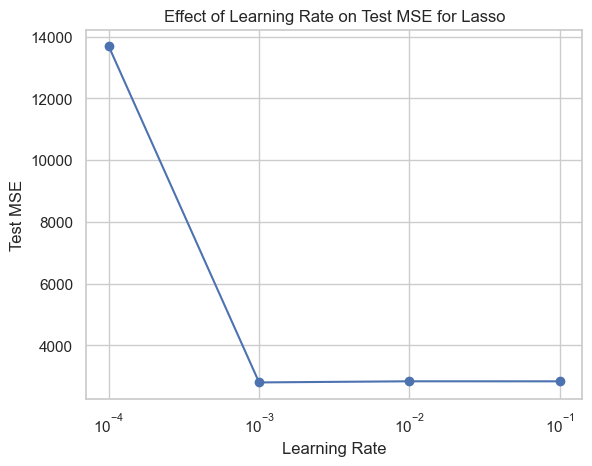

In [22]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]
mse_values = []

print("Penalty = 0.1 and Iterations = 2000 remain unchanged")
print("\n-----------------------------------------------------------")

for learning_rate in learning_rates:
    lasso = LassoRegression(learning_rate = learning_rate, iterations = 2000, penalty = 0.1)
    lasso.fit(X_train, Y_train)
    Y_pred = lasso.predict(X_test)
    mse_value = mse(Y_test, Y_pred)
    print("\nWith Learning Rate = ", learning_rate, ", Lasso Regression has MSE of ", mse_value)
    weights_str = ', '.join(f"{w:.2f}" for w in lasso.weights)
    print("Weights: [", weights_str, "]")
    print("Biases: ", lasso.bias)
    print("\n-----------------------------------------------------------")
    mse_values.append(mse_value)

plt.plot(learning_rates, mse_values, marker='o')
plt.xscale('log')
plt.xlabel('Learning Rate')
plt.ylabel('Test MSE')
plt.title('Effect of Learning Rate on Test MSE for Lasso')
plt.show()

Effect of Iterations on MSE

Penalty = 0.1 and Learning Rate = 0.01 remain unchanged

-----------------------------------------------------------

With Iterations =  100 , Lasso Regression has MSE of  3148.4254301859405
Weights: [ 1.47, -6.53, 22.97, 12.26, -0.47, -4.45, -7.21, 4.18, 18.39, 3.90 ]
Biases:  130.5063131315552

-----------------------------------------------------------

With Iterations =  200 , Lasso Regression has MSE of  2804.4906078596755
Weights: [ -1.63, -8.62, 23.88, 13.35, -0.65, -5.86, -7.70, 4.28, 22.65, 2.66 ]
Biases:  148.18622763398432

-----------------------------------------------------------

With Iterations =  300 , Lasso Regression has MSE of  2827.4885206632957
Weights: [ -2.66, -9.01, 23.52, 13.76, -0.64, -6.11, -7.76, 4.25, 24.15, 2.21 ]
Biases:  150.68299236116655

-----------------------------------------------------------

With Iterations =  400 , Lasso Regression has MSE of  2836.541337681487
Weights: [ -2.95, -9.08, 23.30, 13.92, -0.70, -6.08, -7.76, 4.16, 24.69, 2.05 ]
Bia

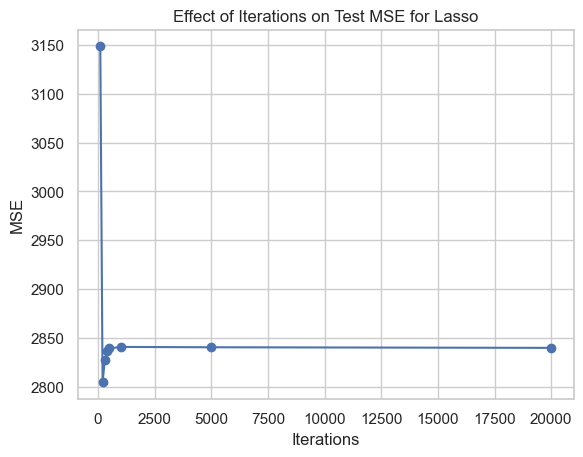

In [23]:
iterations = [100, 200, 300, 400, 500, 1000, 5000, 20000]
mse_values = []

print("Penalty = 0.1 and Learning Rate = 0.01 remain unchanged")
print("\n-----------------------------------------------------------")

for iteration in iterations:
    lasso = LassoRegression(learning_rate = 0.01, iterations = iteration, penalty = 0.1)
    lasso.fit(X_train, Y_train)
    Y_pred = lasso.predict(X_test)
    mse_value = mse(Y_test, Y_pred)
    print("\nWith Iterations = ", iteration, ", Lasso Regression has MSE of ", mse_value)
    weights_str = ', '.join(f"{w:.2f}" for w in lasso.weights)
    print("Weights: [", weights_str, "]")
    print("Biases: ", lasso.bias)
    print("\n-----------------------------------------------------------")
    mse_values.append(mse_value)
    
plt.plot(iterations, mse_values, marker='o')
plt.xlabel('Iterations')
plt.ylabel('MSE')
plt.title('Effect of Iterations on Test MSE for Lasso')
plt.show()

**ElasticNet Regression**

Implementation of ElasticNet Regression

In [24]:
class ElasticNetRegression():

    def __init__(self, learning_rate, iterations, penalty_l1, penalty_l2):

        self.learning_rate = learning_rate
        self.iterations = iterations
        self.penalty_l1 = penalty_l1  # Lambda1
        self.penalty_l2 = penalty_l2  # Lambda2

        self.X = None
        self.Y = None
        self.weights = None
        self.bias = None

    def fit(self, X, Y):

        self.X = X  # 442 rows (patients), 10 (cols) features
        self.Y = Y  # diabetes target values

        self.weights = np.zeros(X.shape[1])  # a vector of 0s with length 10, one for each feature, starting with 0s
        self.bias = 0  # starting bias is 0

        for i in range(self.iterations):
            self.update_weights()

    def update_weights(self):

        sample_number = self.X.shape[0]
        Y_pred = self.predict(self.X)

        dw = (2 / sample_number) * (self.X.T @ (Y_pred - self.Y)) + 2 * self.penalty_l2 * self.weights  # MSE and l2
        db = (2 / sample_number) * np.sum(Y_pred - self.Y)

        self.weights -= self.learning_rate * dw
        self.bias -= self.learning_rate * db

        # Soft thresholding: S(z) = sign(z) · max(|z| − ηλ , 0)
        self.weights = np.sign(self.weights) * np.maximum(np.abs(self.weights) - self.learning_rate * self.penalty_l1, 0)

    def predict(self, X):

        return X @ self.weights + self.bias

Effect of L1 Penalty on MSE

Learning Rate = 0.01, Iterations = 2000, and L2 Penalty = 0.1 remain unchanged

-----------------------------------------------------------

With L1 Penalty =  0 , ElasticNet Regression has MSE of  2843.343472563682
Weights: [ -2.24, -8.19, 21.49, 13.30, -0.55, -5.05, -7.64, 4.32, 22.49, 2.75 ]
Biases:  151.0450112459831

-----------------------------------------------------------

With L1 Penalty =  0.001 , ElasticNet Regression has MSE of  2843.3639204746337
Weights: [ -2.24, -8.19, 21.49, 13.30, -0.55, -5.05, -7.65, 4.32, 22.49, 2.75 ]
Biases:  151.04493794952953

-----------------------------------------------------------

With L1 Penalty =  0.01 , ElasticNet Regression has MSE of  2843.5482062146502
Weights: [ -2.23, -8.18, 21.49, 13.30, -0.54, -5.05, -7.65, 4.31, 22.49, 2.74 ]
Biases:  151.04427828144657

-----------------------------------------------------------

With L1 Penalty =  0.1 , ElasticNet Regression has MSE of  2845.4162676907827
Weights: [ -2.17, -8.11, 21.47, 13.25,

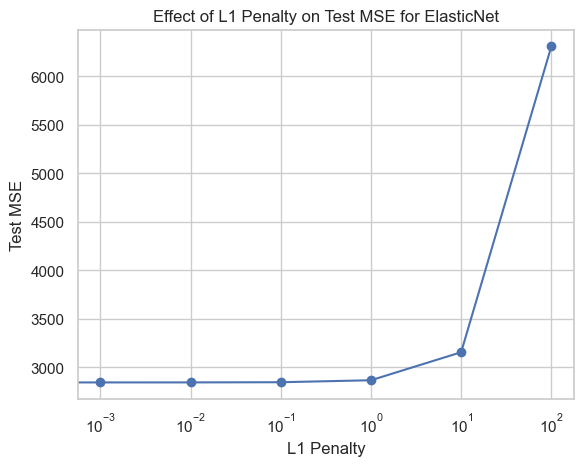

In [25]:
penalties_l1 = [0, 0.001, 0.01, 0.1, 1, 10, 100]
mse_values = []

print("Learning Rate = 0.01, Iterations = 2000, and L2 Penalty = 0.1 remain unchanged")
print("\n-----------------------------------------------------------")

for penalty_l1 in penalties_l1:
    elasticNet = ElasticNetRegression(learning_rate = 0.01, iterations = 2000, penalty_l1 = penalty_l1, penalty_l2 = 0.1)
    elasticNet.fit(X_train, Y_train)
    Y_pred = elasticNet.predict(X_test)
    mse_value = mse(Y_test, Y_pred)
    print("\nWith L1 Penalty = ", penalty_l1, ", ElasticNet Regression has MSE of ", mse_value)
    weights_str = ', '.join(f"{w:.2f}" for w in elasticNet.weights)
    print("Weights: [", weights_str, "]")
    print("Biases: ", elasticNet.bias)
    print("\n-----------------------------------------------------------")
    mse_values.append(mse_value)
    
plt.plot(penalties_l1, mse_values, marker='o')
plt.xscale('log')
plt.xlabel('L1 Penalty')
plt.ylabel('Test MSE')
plt.title('Effect of L1 Penalty on Test MSE for ElasticNet')
plt.show()

Effect of L2 Penalty on MSE

Learning Rate = 0.01, Iterations = 2000, and L1 Penalty = 0.1 remain unchanged

-----------------------------------------------------------

With L2 Penalty =  0 , ElasticNet Regression has MSE of  2859.8894798991796
Weights: [ -2.41, -8.21, 22.86, 13.44, -0.74, -3.39, -9.22, 0.37, 25.52, 1.50 ]
Biases:  151.07779078137582

-----------------------------------------------------------

With L2 Penalty =  0.001 , ElasticNet Regression has MSE of  2859.736863633029
Weights: [ -2.40, -8.20, 22.84, 13.44, -0.71, -3.43, -9.21, 0.41, 25.47, 1.51 ]
Biases:  151.07658037984305

-----------------------------------------------------------

With L2 Penalty =  0.01 , ElasticNet Regression has MSE of  2858.636333328053
Weights: [ -2.32, -8.13, 22.70, 13.38, -0.45, -3.72, -9.08, 0.78, 25.05, 1.60 ]
Biases:  151.06583866489763

-----------------------------------------------------------

With L2 Penalty =  0.1 , ElasticNet Regression has MSE of  2865.7328659130335
Weights: [ -1.58, -7.39, 21.28, 12.79,

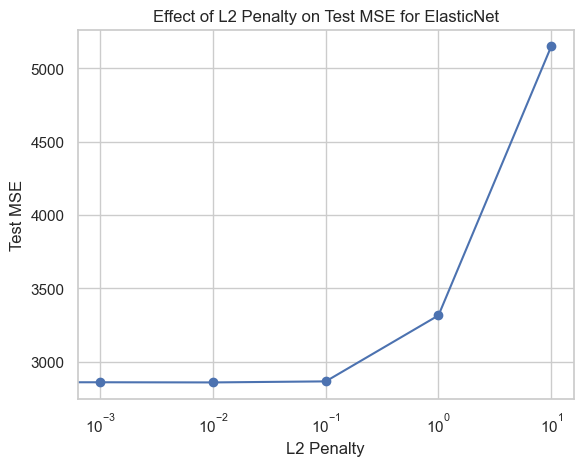

In [26]:
penalties_l2 = [0, 0.001, 0.01, 0.1, 1, 10]
mse_values = []

print("Learning Rate = 0.01, Iterations = 2000, and L1 Penalty = 0.1 remain unchanged")
print("\n-----------------------------------------------------------")

for penalty_l2 in penalties_l2:
    elasticNet = ElasticNetRegression(learning_rate = 0.01, iterations = 2000, penalty_l2 = penalty_l2, penalty_l1 = 1)
    elasticNet.fit(X_train, Y_train)
    Y_pred = elasticNet.predict(X_test)
    mse_value = mse(Y_test, Y_pred)
    print("\nWith L2 Penalty = ", penalty_l2, ", ElasticNet Regression has MSE of ", mse_value)
    weights_str = ', '.join(f"{w:.2f}" for w in elasticNet.weights)
    print("Weights: [", weights_str, "]")
    print("Biases: ", elasticNet.bias)
    print("\n-----------------------------------------------------------")
    mse_values.append(mse_value)
    
plt.plot(penalties_l2, mse_values, marker='o')
plt.xscale('log')
plt.xlabel('L2 Penalty')
plt.ylabel('Test MSE')
plt.title('Effect of L2 Penalty on Test MSE for ElasticNet')
plt.show()

Effect of Learning Rate on MSE

Iterations = 2000, L1 and L2 Penalty = 0.1 remain unchanged

-----------------------------------------------------------

With Learning Rate =  0.0001 , ElasticNet Regression has MSE of  13709.177366153299
Weights: [ 3.80, -0.77, 11.09, 6.76, 1.53, 0.34, -4.39, 3.90, 8.27, 4.01 ]
Biases:  49.44672307470358

-----------------------------------------------------------

With Learning Rate =  0.001 , ElasticNet Regression has MSE of  2826.9536709455465
Weights: [ -1.13, -7.71, 22.07, 12.74, -0.32, -5.03, -7.52, 4.40, 20.90, 3.09 ]
Biases:  148.03839955950778

-----------------------------------------------------------

With Learning Rate =  0.01 , ElasticNet Regression has MSE of  2845.4162676907827
Weights: [ -2.17, -8.11, 21.47, 13.25, -0.46, -4.98, -7.70, 4.16, 22.46, 2.70 ]
Biases:  151.03768166210136

-----------------------------------------------------------

With Learning Rate =  0.1 , ElasticNet Regression has MSE of  2845.4173257197062
Weights: [ -2.17, -8.11, 21.47, 13.25, -0.47

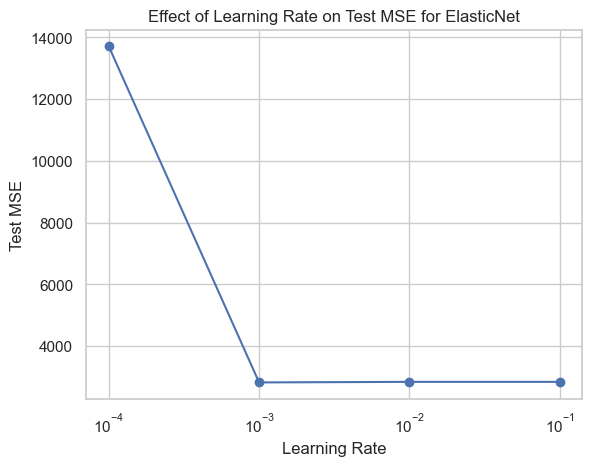

In [27]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]
mse_values = []

print("Iterations = 2000, L1 and L2 Penalty = 0.1 remain unchanged")
print("\n-----------------------------------------------------------")

for learning_rate in learning_rates:
    elasticNet = ElasticNetRegression(learning_rate = learning_rate, iterations = 2000, penalty_l1 = 0.1, penalty_l2 = 0.1)
    elasticNet.fit(X_train, Y_train)
    Y_pred = elasticNet.predict(X_test)
    mse_value = mse(Y_test, Y_pred)
    print("\nWith Learning Rate = ", learning_rate, ", ElasticNet Regression has MSE of ", mse_value)
    weights_str = ', '.join(f"{w:.2f}" for w in elasticNet.weights)
    print("Weights: [", weights_str, "]")
    print("Biases: ", elasticNet.bias)
    print("\n-----------------------------------------------------------")
    mse_values.append(mse_value)
    
plt.plot(learning_rates, mse_values, marker='o')
plt.xscale('log')
plt.xlabel('Learning Rate')
plt.ylabel('Test MSE')
plt.title('Effect of Learning Rate on Test MSE for ElasticNet')
plt.show()

Effect of Iterations on MSE

Learning Rate = 0.01, L1 and L2 Penalty = 0.1 remain unchanged

-----------------------------------------------------------

With Iterations =  100 , ElasticNet Regression has MSE of  3189.3697667687716
Weights: [ 1.52, -6.00, 21.61, 11.77, -0.25, -3.94, -7.01, 4.23, 17.46, 3.97 ]
Biases:  130.49027342631237

-----------------------------------------------------------

With Iterations =  200 , ElasticNet Regression has MSE of  2826.9277657547727
Weights: [ -1.15, -7.72, 22.08, 12.74, -0.32, -5.04, -7.52, 4.40, 20.92, 3.08 ]
Biases:  148.13863677808996

-----------------------------------------------------------

With Iterations =  300 , ElasticNet Regression has MSE of  2839.0290726251355
Weights: [ -1.92, -8.03, 21.72, 13.08, -0.28, -5.22, -7.62, 4.40, 21.95, 2.82 ]
Biases:  150.60374887099752

-----------------------------------------------------------

With Iterations =  400 , ElasticNet Regression has MSE of  2843.6767959846125
Weights: [ -2.11, -8.09, 21.56, 13.20, -0.29, -5.22, -

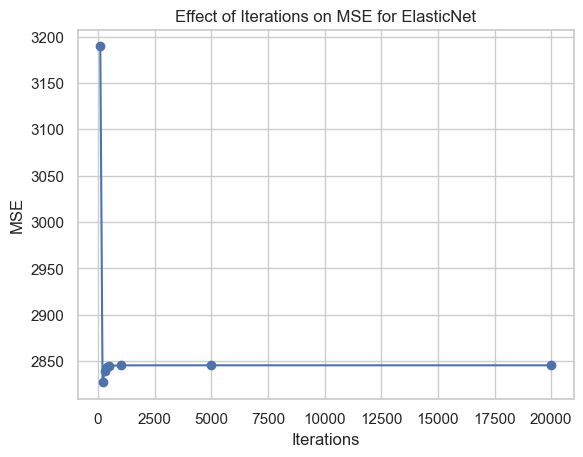

In [28]:
iterations = [100, 200, 300, 400, 500, 1000, 5000, 20000]
mse_values = []

print("Learning Rate = 0.01, L1 and L2 Penalty = 0.1 remain unchanged")
print("\n-----------------------------------------------------------")

for iteration in iterations:
    elasticNet = ElasticNetRegression(learning_rate = 0.01, iterations = iteration, penalty_l1 = 0.1, penalty_l2 = 0.1)
    elasticNet.fit(X_train, Y_train)
    Y_pred = elasticNet.predict(X_test)
    mse_value = mse(Y_test, Y_pred)
    print("\nWith Iterations = ", iteration, ", ElasticNet Regression has MSE of ", mse_value)
    weights_str = ', '.join(f"{w:.2f}" for w in elasticNet.weights)
    print("Weights: [", weights_str, "]")
    print("Biases: ", elasticNet.bias)
    print("\n-----------------------------------------------------------")
    mse_values.append(mse_value)
    
plt.plot(iterations, mse_values, marker='o')
plt.xlabel('Iterations')
plt.ylabel('MSE')
plt.title('Effect of Iterations on MSE for ElasticNet')
plt.show()

Compare with sklearn Regressions

Test MSE for my model: 2845.4162676907827
Test MSE for sklearn model: 2839.1291372284995
Test MSE for my model: 2840.9700183151785
Test MSE for sklearn model: 2841.7535388718265


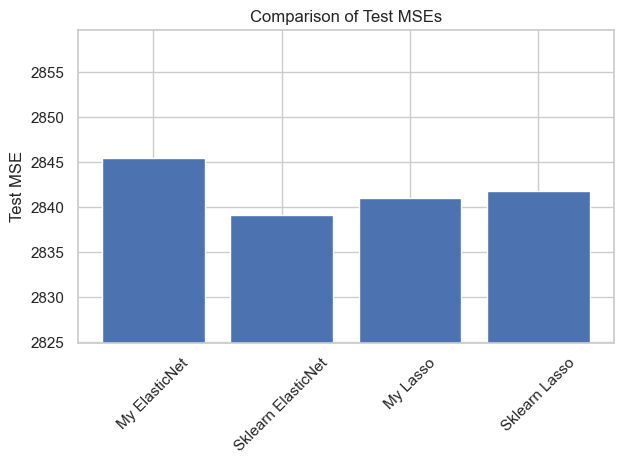

In [29]:
my_model = ElasticNetRegression(learning_rate = 0.01, iterations = 2000, penalty_l1 = 0.1, penalty_l2 = 0.1)
my_model.fit(X_train, Y_train)

sklearn_model = ElasticNet(alpha = 0.1, l1_ratio = 0.5, max_iter = 2000)
sklearn_model.fit(X_train, Y_train)

my_Y_pred = my_model.predict(X_test)
sklearn_Y_pred = sklearn_model.predict(X_test)

my_mse = np.mean((Y_test - my_Y_pred) ** 2)
sklearn_mse = np.mean((Y_test - sklearn_Y_pred) ** 2)

print("Test MSE for my model:", my_mse)
print("Test MSE for sklearn model:", sklearn_mse)

my_model = LassoRegression(learning_rate = 0.01, iterations = 2000, penalty = 0.1)
my_model.fit(X_train, Y_train)

sklearn_model = Lasso(alpha = 0.1, max_iter = 2000)
sklearn_model.fit(X_train, Y_train)

my_Y_pred = my_model.predict(X_test)
sklearn_Y_pred = sklearn_model.predict(X_test)

print("Test MSE for my model:", mse(Y_test, my_Y_pred))
print("Test MSE for sklearn model:", mse(Y_test, sklearn_Y_pred))

mse_values = [
    my_mse,                  
    sklearn_mse,           
    mse(Y_test, my_Y_pred), 
    mse(Y_test, sklearn_Y_pred)  
]

labels = [
    "My ElasticNet",
    "Sklearn ElasticNet",
    "My Lasso",
    "Sklearn Lasso"
]

plt.figure()
plt.bar(labels, mse_values)

plt.ylabel("Test MSE")
plt.title("Comparison of Test MSEs")
plt.xticks(rotation=45)

plt.ylim(min(mse_values)*0.995, max(mse_values)*1.005)

plt.tight_layout()
plt.show()

**Multiclass SVM**

Implementation of Mutliclass SVM

In [30]:
class MulticlassSVM():

    def __init__(self, learning_rate, lambda_param, n_iters):

        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.weights = None  #shape: (n_classes, n_features), initialized later
        self.biases = None   #shape: (n_classes,), initialized later

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes = np.unique(y) #number of classes
        n_classes = len(self.classes)

        #Initialize weights and biases
        self.weights = np.zeros((n_classes, n_features))
        self.biases = np.zeros(n_classes)

        #Train one-vs-rest classifiers
        for idx, cls in enumerate(self.classes):
            #Create binary labels for current class
            y_binary = np.where(y == cls, 1, -1)

            w = np.zeros(n_features)
            b = 0
            
            #Gradient descent
            for _ in range(self.n_iters):
                for i in range(n_samples):
                    condition = y_binary[i] * (np.dot(X[i], w) + b) >= 1

                    if condition:
                        dw = 2 * self.lambda_param * w
                        db = 0
                    else:
                        dw = 2 * self.lambda_param * w - y_binary[i] * X[i]
                        db = -y_binary[i]

                    #update weight and bias
                    w -= self.lr * dw
                    b -= self.lr * db

            self.weights[idx] = w
            self.biases[idx] = b


    def predict(self, X):
        #decision scores for each class
        scores = np.dot(X, self.weights.T) + self.biases
        #choose class with highest score
        return self.classes[np.argmax(scores, axis=1)]

**Load digits dataset**

In [31]:
digits = load_digits()
X = digits.data
y = digits.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

Effect of Lambda on Train and Test Accuracy

Lambda=0.001, Train acc=0.9777, Test acc=0.9370
Lambda=0.01, Train acc=0.9730, Test acc=0.9556
Lambda=0.1, Train acc=0.9387, Test acc=0.9333


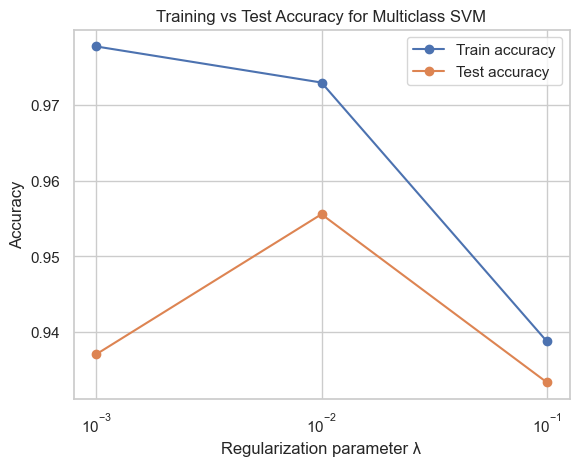

In [32]:
lambda_values = [0.001, 0.01, 0.1]
train_accuracies = []
test_accuracies = []
models = {}

for lam in lambda_values:
    svm = MulticlassSVM(
        learning_rate=0.001,
        lambda_param=lam,
        n_iters=1000
    )

    svm.fit(X_train, y_train)

    y_train_pred = svm.predict(X_train)
    y_test_pred = svm.predict(X_test)

    train_acc = np.mean(y_train_pred == y_train)
    test_acc = np.mean(y_test_pred == y_test)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    models[lam] = svm

    print(f"Lambda={lam}, Train acc={train_acc:.4f}, Test acc={test_acc:.4f}")
    
plt.plot(lambda_values, train_accuracies, marker='o', label="Train accuracy")
plt.plot(lambda_values, test_accuracies, marker='o', label="Test accuracy")
plt.xscale('log')
plt.xlabel("Regularization parameter λ")
plt.ylabel("Accuracy")
plt.title("Training vs Test Accuracy for Multiclass SVM")
plt.legend()
plt.grid(True)
plt.show()

Confusion Matrix for the best Lambda (0.01)

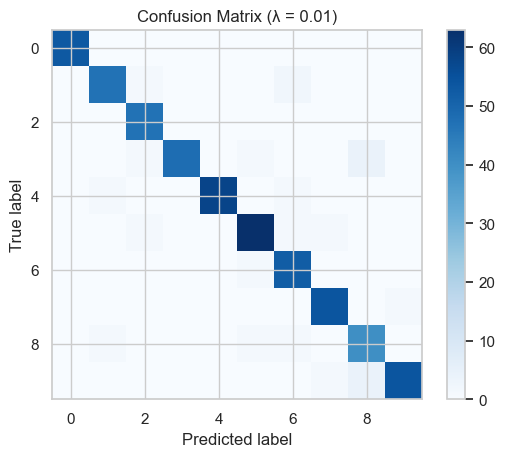

In [33]:
best_lambda = lambda_values[np.argmax(test_accuracies)]
best_model = models[best_lambda]

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Confusion Matrix (λ = {best_lambda})")
plt.show()

Effect of Learning Rate on Test Accuracy

Learning rate = 0.0001, Test accuracy = 0.9537
Learning rate = 0.001, Test accuracy = 0.9556
Learning rate = 0.01, Test accuracy = 0.9056


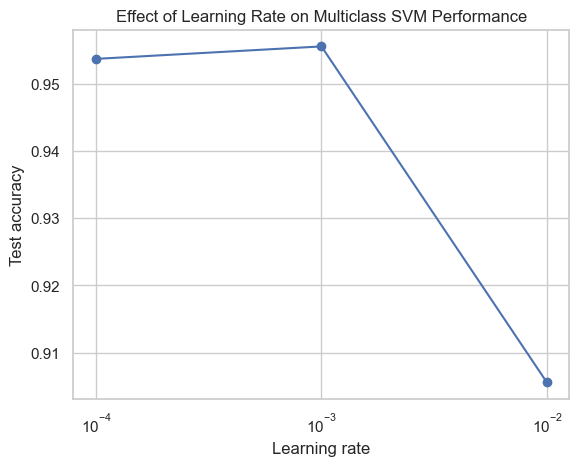

In [34]:
learning_rates = [0.0001, 0.001, 0.01]
test_accuracies_lr = []

for lr in learning_rates:
    svm = MulticlassSVM(
        learning_rate=lr,
        lambda_param=0.01,   # keep λ fixed
        n_iters=1000         # keep iterations fixed
    )

    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    acc = np.mean(y_pred == y_test)

    test_accuracies_lr.append(acc)
    print(f"Learning rate = {lr}, Test accuracy = {acc:.4f}")

plt.plot(learning_rates, test_accuracies_lr, marker='o')
plt.xscale('log')
plt.xlabel("Learning rate")
plt.ylabel("Test accuracy")
plt.title("Effect of Learning Rate on Multiclass SVM Performance")
plt.grid(True)
plt.show()

**Multilayer Perceptron (MLP)**

Implementation of MLP

In [35]:
class MLP():

    def __init__(self, input_size, hidden_size, output_size, lr):

        self.lr = lr

        self.input_hidden_weights = np.random.randn(input_size, hidden_size)  # every line has a weight
        self.hidden_biases = np.zeros((1, hidden_size))  # every neuron has a bias
        self.hidden_output_weights = np.random.randn(hidden_size, output_size)
        self.output_biases = np.zeros((1, output_size))

    def relu(self, Z):

        return np.maximum(0, Z)

    def relu_derivative(self, Z):

        return (Z > 0).astype(float)

    def softmax(self, Z):

        e_to_z = np.exp(Z)
        softmax_result = e_to_z / np.sum(e_to_z, axis=1, keepdims=True)
        return softmax_result

    def fit(self, X, y, epochs):

        sample_number = X.shape[0]

        for i in range(epochs):

            # forward pass
            Z_hidden = X @ self.input_hidden_weights + self.hidden_biases  # Z = XW + b
            activated_Z_hidden = self.relu(Z_hidden)
            Z_output = activated_Z_hidden @ self.hidden_output_weights + self.output_biases
            y_pred = self.softmax(Z_output)

            # backpropagate
            output_error = y_pred - y
            hidden_error = output_error @ self.hidden_output_weights.T * self.relu_derivative(Z_hidden)

            dZ_output = output_error
            dZ_hidden = hidden_error

            dhidden_output_weights = activated_Z_hidden.T @ dZ_output / sample_number
            doutput_biases = np.sum(dZ_output, axis = 0) / sample_number
            dinput_hidden_weights = X.T @ dZ_hidden / sample_number
            dhidden_biases = np.sum(dZ_hidden, axis = 0) / sample_number

            # update weights and biases
            self.hidden_output_weights -= self.lr * dhidden_output_weights
            self.output_biases -= self.lr * doutput_biases
            self.input_hidden_weights -= self.lr * dinput_hidden_weights
            self.hidden_biases -= self.lr * dhidden_biases

    def predict(self, X):

        Z_hidden = X @ self.input_hidden_weights + self.hidden_biases  # Z = XW + b
        activated_Z_hidden = self.relu(Z_hidden)
        Z_output = activated_Z_hidden @ self.hidden_output_weights + self.output_biases
        y_pred = self.softmax(Z_output)
        return np.argmax(y_pred, axis=1)  # the class with the most possibility

Digits dataset preprocessing

In [36]:
digits = load_digits()
X = digits.data
y = digits.target

X = X / 16.0  # normalizing pixels from [0, 16] to [0, 1] such that exp() will not explode

encoder = OneHotEncoder(sparse_output = False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))  # one hot encoder for the output, turning digit to 1/0

X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size = 0.3, random_state = 42)

Effect of Hidden Layer Size on Test Accuracy

Learning Rate = 0.1, and Epochs = 2000 remain unchanged

-----------------------------------------------------------

With Hidden Layer Size =  2 , MLP has Test Accuracy of  0.5222222222222223

-----------------------------------------------------------

With Hidden Layer Size =  4 , MLP has Test Accuracy of  0.5166666666666667

-----------------------------------------------------------

With Hidden Layer Size =  8 , MLP has Test Accuracy of  0.9111111111111111

-----------------------------------------------------------

With Hidden Layer Size =  16 , MLP has Test Accuracy of  0.9351851851851852

-----------------------------------------------------------

With Hidden Layer Size =  32 , MLP has Test Accuracy of  0.9518518518518518

-----------------------------------------------------------

With Hidden Layer Size =  64 , MLP has Test Accuracy of  0.9462962962962963

-----------------------------------------------------------

With Hidden Layer Size =  128 , MLP has Test Accuracy of 

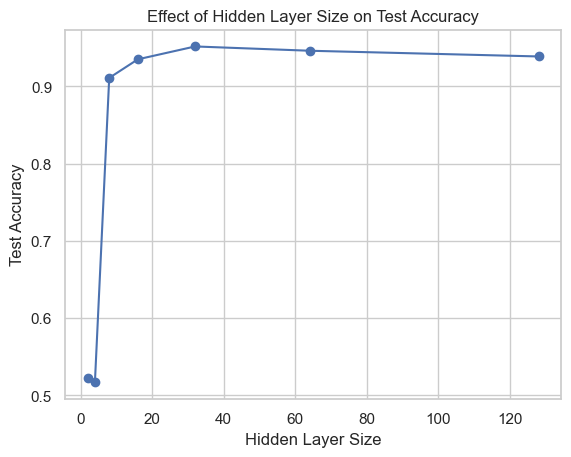

In [37]:
hidden_layer_sizes = [2, 4, 8, 16, 32, 64, 128]
accuracy_values = []

print("Learning Rate = 0.1, and Epochs = 2000 remain unchanged")
print("\n-----------------------------------------------------------")

for hidden_layer_size in hidden_layer_sizes:
    mlp = MLP(input_size = 64, hidden_size = hidden_layer_size, output_size = 10, lr = 0.1)
    mlp.fit(X_train, y_train, epochs = 2000)
    y_pred = mlp.predict(X_test)
    y_test_labels = np.argmax(y_test, axis = 1)
    acc = accuracy_score(y_test_labels, y_pred)
    print("\nWith Hidden Layer Size = ", hidden_layer_size, ", MLP has Test Accuracy of ", acc)
    print("\n-----------------------------------------------------------")
    accuracy_values.append(acc)
    
plt.plot(hidden_layer_sizes, accuracy_values, marker='o')
plt.xlabel('Hidden Layer Size')
plt.ylabel('Test Accuracy')
plt.title('Effect of Hidden Layer Size on Test Accuracy')
plt.show()

Effect of Learning Rate on Test Accuracy

Hidden Layer Size = 32, and Epochs = 2000 remain unchanged

-----------------------------------------------------------

With Learning Rate =  0.0001 , MLP has Test Accuracy of  0.12037037037037036

-----------------------------------------------------------

With Learning Rate =  0.001 , MLP has Test Accuracy of  0.5351851851851852

-----------------------------------------------------------

With Learning Rate =  0.01 , MLP has Test Accuracy of  0.8611111111111112

-----------------------------------------------------------

With Learning Rate =  0.1 , MLP has Test Accuracy of  0.9462962962962963

-----------------------------------------------------------


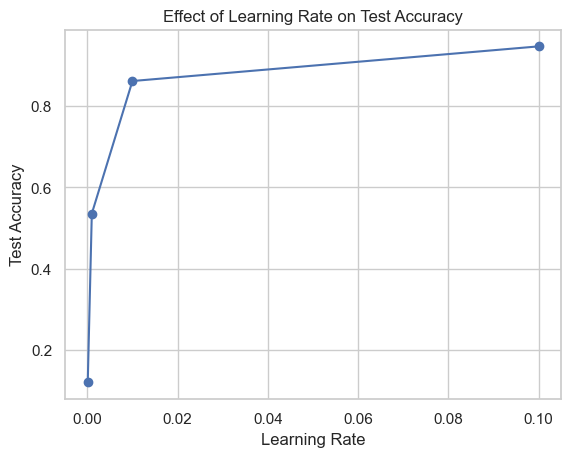

In [38]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]
accuracy_values = []

print("Hidden Layer Size = 32, and Epochs = 2000 remain unchanged")
print("\n-----------------------------------------------------------")

for learning_rate in learning_rates:
    mlp = MLP(input_size = 64, hidden_size = 32, output_size = 10, lr = learning_rate)
    mlp.fit(X_train, y_train, epochs = 2000)
    y_pred = mlp.predict(X_test)
    y_test_labels = np.argmax(y_test, axis = 1)
    acc = accuracy_score(y_test_labels, y_pred)
    print("\nWith Learning Rate = ", learning_rate, ", MLP has Test Accuracy of ", acc)
    print("\n-----------------------------------------------------------")
    accuracy_values.append(acc)
    
plt.plot(learning_rates, accuracy_values, marker='o')
plt.xlabel('Learning Rate')
plt.ylabel('Test Accuracy')
plt.title('Effect of Learning Rate on Test Accuracy')
plt.show()

Effect of Epochs on Test Accuracy

Hidden Layer Size = 32, and Learning Rate = 0.1 remain unchanged

-----------------------------------------------------------

With Epochs =  100 , MLP has Test Accuracy of  0.7351851851851852

-----------------------------------------------------------

With Epochs =  500 , MLP has Test Accuracy of  0.8907407407407407

-----------------------------------------------------------

With Epochs =  1000 , MLP has Test Accuracy of  0.937037037037037

-----------------------------------------------------------

With Epochs =  2000 , MLP has Test Accuracy of  0.9388888888888889

-----------------------------------------------------------

With Epochs =  5000 , MLP has Test Accuracy of  0.9425925925925925

-----------------------------------------------------------

With Epochs =  10000 , MLP has Test Accuracy of  0.9611111111111111

-----------------------------------------------------------


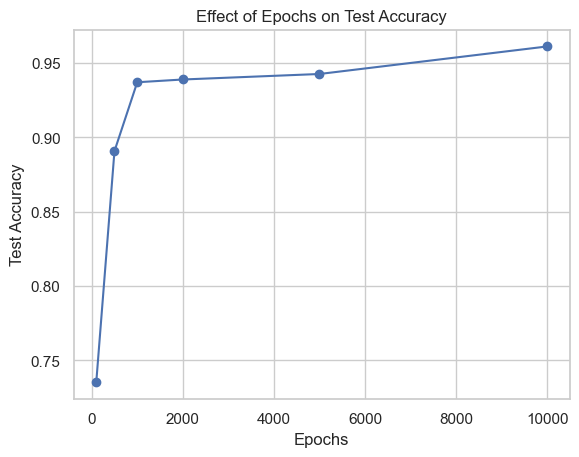

In [39]:
epochs_list = [100, 500, 1000, 2000, 5000, 10000]
accuracy_values = []

print("Hidden Layer Size = 32, and Learning Rate = 0.1 remain unchanged")
print("\n-----------------------------------------------------------")

for epochs in epochs_list:
    mlp = MLP(input_size = 64, hidden_size = 32, output_size = 10, lr = 0.1)
    mlp.fit(X_train, y_train, epochs = epochs)
    y_pred = mlp.predict(X_test)
    y_test_labels = np.argmax(y_test, axis = 1)
    acc = accuracy_score(y_test_labels, y_pred)
    print("\nWith Epochs = ", epochs, ", MLP has Test Accuracy of ", acc)
    print("\n-----------------------------------------------------------")
    accuracy_values.append(acc)
    
plt.plot(epochs_list, accuracy_values, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Test Accuracy')
plt.title('Effect of Epochs on Test Accuracy')
plt.show()

Compare with sklearn Random Forest Classifier


Test Accuracy for my MLP: 0.8666666666666667

Test Accuracy for sklearn Random Forest: 0.9703703703703703


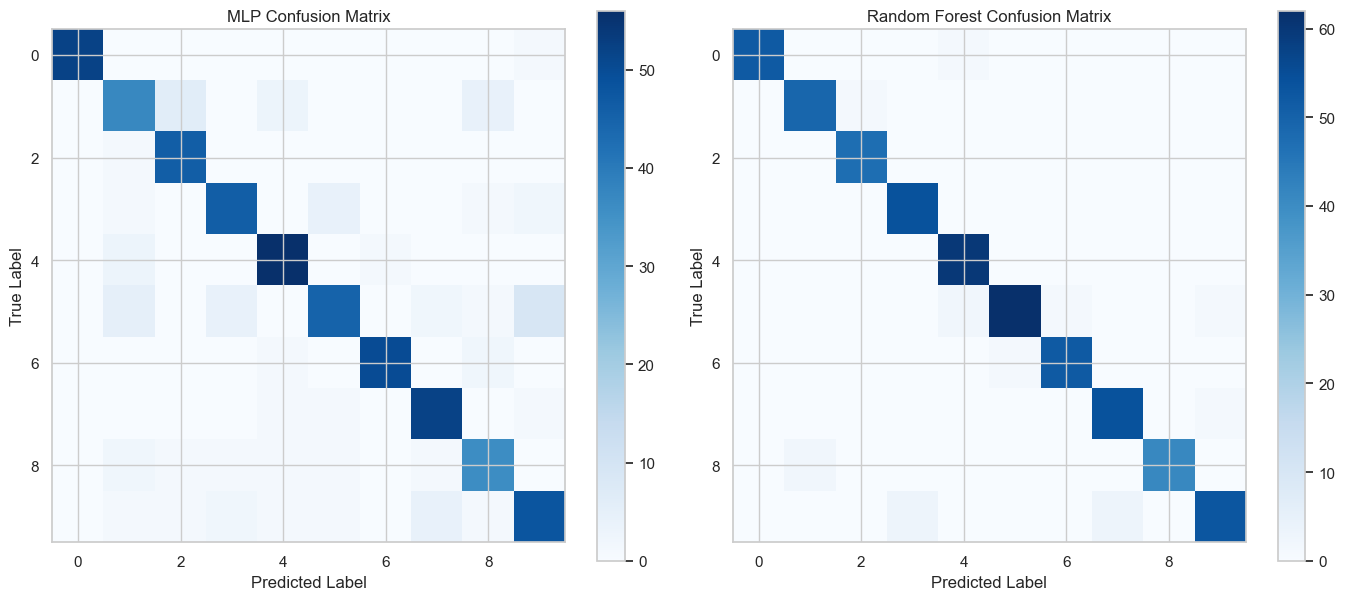

In [40]:
y_train_labels = np.argmax(y_train, axis=1)
y_test_labels  = np.argmax(y_test, axis=1)

mlp = MLP(input_size=64, hidden_size=16, output_size=10, lr=0.1)
mlp.fit(X_train, y_train, epochs=1000)
my_y_pred = mlp.predict(X_test)
my_acc = accuracy_score(y_test_labels, my_y_pred)

sklearn_model = RandomForestClassifier(
    n_estimators=30,
    max_depth=None,
    random_state=42
)
sklearn_model.fit(X_train, y_train_labels)
sklearn_y_pred = sklearn_model.predict(X_test)
sklearn_acc = accuracy_score(y_test_labels, sklearn_y_pred)

print("\nTest Accuracy for my MLP:", my_acc)
print("\nTest Accuracy for sklearn Random Forest:", sklearn_acc)

cm_mlp = confusion_matrix(y_test_labels, my_y_pred)
cm_rf  = confusion_matrix(y_test_labels, sklearn_y_pred)

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.imshow(cm_mlp, cmap='Blues')
plt.title("MLP Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(cm_rf, cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.tight_layout()
plt.show()